**ECE 447: Data Analysis and Machine Learning for Engineers**

# Assignment 3 - Problem 3
**Regression: Linear Regression**

In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
#### A3-P3 This problem focuses on linear regression.
# The dataset (nba-games.csv) contains statistics from the National Basketball Association (NBA).
# The goal is to estimate team skill levels (one per team) using linear regression on game scores.

In [ ]:
#### A3-P3 a) Load the data and remove any games containing missing values (hint: you should end up with 26,552 games).

# paths
path = "data"
nhl_path = os.path.join(path, "nba_games.csv")

# load
df_org = pd.read_csv(nhl_path)
df_org.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [5]:
before = len(df_org)
df = df_org.dropna().reset_index(drop=True)
after = len(df)

print(before, after)

26651 26552


In [ ]:
#### A3-P3 b)

def create_X_from_teams(df):
    # unique teams
    teams = pd.Index(pd.concat([df["HOME_TEAM_ID"], df["VISITOR_TEAM_ID"]]).unique())

    # map team_id -> column index
    team_to_col = {team: i for i, team in enumerate(teams)}
    print(team_to_col)

    # initialize X
    n_games = len(df)
    n_teams = len(teams)
    print("n_games", n_games)
    print("n_teams", n_teams)

    X = np.zeros((n_games, n_teams))

    # fill X with +1 (home) and -1 (away)
    win_score = np.zeros((n_teams))
    for i, row in df.iterrows():
        X[i, team_to_col[row["HOME_TEAM_ID"]]] =  1.0
        X[i, team_to_col[row["VISITOR_TEAM_ID"]]] = -1.0

        if row["HOME_TEAM_WINS"]:
            win_score[team_to_col[row["HOME_TEAM_ID"]]] += 3
        else:
            win_score[team_to_col[row["VISITOR_TEAM_ID"]]] += 3

    return X, win_score

X_games_wobias, win_score = create_X_from_teams(df)

# Target
df["home_win_score"] = df["PTS_home"] - df["PTS_away"]
y_games = df["home_win_score"].to_numpy()
y_games = y_games.reshape(y_games.shape[0], 1)

print("X_games_wobias shape:", X_games_wobias.shape)
print("y_games shape:", y_games.shape)
print("win_score", win_score.shape)

{1610612740: 0, 1610612762: 1, 1610612739: 2, 1610612755: 3, 1610612737: 4, 1610612738: 5, 1610612751: 6, 1610612752: 7, 1610612745: 8, 1610612750: 9, 1610612760: 10, 1610612758: 11, 1610612746: 12, 1610612765: 13, 1610612748: 14, 1610612756: 15, 1610612743: 16, 1610612754: 17, 1610612761: 18, 1610612747: 19, 1610612759: 20, 1610612749: 21, 1610612766: 22, 1610612741: 23, 1610612742: 24, 1610612763: 25, 1610612753: 26, 1610612764: 27, 1610612757: 28, 1610612744: 29}
n_games 26552
n_teams 30
X_games_wobias shape: (26552, 30)
y_games shape: (26552, 1)
win_score (30,)


In [7]:
# adding the bias
home_advantage = np.ones((X_games_wobias.shape[0], 1))
X_games = np.concatenate([X_games_wobias, home_advantage], axis=1)
print("X_games", X_games.shape)

X_games (26552, 31)


In [8]:
teams = pd.Index(pd.concat([df["HOME_TEAM_ID"], df["VISITOR_TEAM_ID"]]).unique())

In [ ]:
#### A3-P3 c)

X_games_train, X_games_test, y_games_train, y_games_test = train_test_split(
    X_games, y_games,
    test_size=0.2,
    random_state=0
)
print("X_games_train.shape", X_games_train.shape, "y_games_train", y_games_train.shape)
print("X_games_test.shape", X_games_test.shape, "y_games_test", y_games_test.shape)

X_games_train.shape (21241, 31) y_games_train (21241, 1)
X_games_test.shape (5311, 31) y_games_test (5311, 1)


In [ ]:
#### A3-P3 d)

r = np.linalg.matrix_rank(X_games_train)
print("rank is", r)

rank is 30


In [ ]:
#### A3-P3 e,f)

## compute LS solution
def do_ls_for_nba(X, y):
    XTX = np.dot(X.T, X)
    print("XTX.shape", XTX.shape)

    XTy = np.dot(X.T, y)
    print("XTy.shape", XTy.shape)

    print(np.sum(y))

    theta_ls = np.dot(np.linalg.inv(XTX),XTy)
    return theta_ls

theta_games_ls = do_ls_for_nba(X_games_train, y_games_train)

print("Estimated skill level of each team is")
print("skills", theta_games_ls[:-1])
print("home advantage", theta_games_ls[-1])

# the bias gives advantage to the home team, hence, it's positive.

XTX.shape (31, 31)
XTy.shape (31, 1)
58851.0
Estimated skill level of each team is
skills [[ -1.39314348]
 [ -4.39084663]
 [-10.77094686]
 [ -6.08031566]
 [ -4.7166437 ]
 [ -4.76006549]
 [ -9.73016104]
 [ -9.73632879]
 [  2.72670895]
 [ -6.78143058]
 [ -8.35518879]
 [-11.41704526]
 [ -2.77656448]
 [ -6.01281757]
 [ -3.38099179]
 [ -6.79941528]
 [ -7.64692616]
 [ -0.70095727]
 [ -4.77843878]
 [ -4.87020541]
 [  0.66819632]
 [ -5.06186129]
 [ -9.72915756]
 [ -5.11825016]
 [ -4.71337692]
 [ -5.75758443]
 [ -9.08785089]
 [-12.67700574]
 [-10.66243547]
 [  0.13935468]]
home advantage [2.77039863]


In [ ]:
#### A3-P3 g)

## do prediction train
y_games_pred_train = np.dot(X_games_train, theta_games_ls)
print("train R²:", r2_score(y_games_train, y_games_pred_train))
print("train RMSE:", np.sqrt(mean_squared_error(y_games_train, y_games_pred_train)))

## do prediction
y_games_pred_test = np.dot(X_games_test, theta_games_ls)
print("R²:", r2_score(y_games_test, y_games_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_games_test, y_games_pred_test)))

train R²: -0.05614517724554857
train RMSE: 13.922953490439752
R²: -0.06192144699026558
RMSE: 13.807975285780607


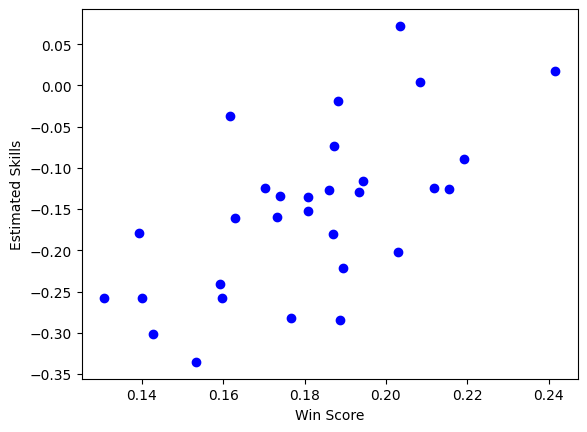

In [ ]:
#### A3-P3 h)

skills_normalized = theta_games_ls[:-1]/np.linalg.norm(theta_games_ls[:-1])
win_score_normalized = win_score/np.linalg.norm(win_score)

plt.plot(win_score_normalized, skills_normalized, "o", color="blue")
plt.xlabel("Win Score")
plt.ylabel("Estimated Skills");

# so, we did not expect to have good prediction as the model is very simple
# and it's indeed very hard to predict the result of a game by a very simple model

# However, what we have been able to achieve is to learn a skill level for each team
# which positively correlates with the win score (hence, correct learning and implementation).
# This is a reasonable approximation.

